The [dataset](https://www.kaggle.com/datasets/fatimafarzand/global-petrol-prices-april-2026) contains the petrol prices for the month of April 2026 and the analysis is inspired by [this](https://www.kaggle.com/code/pavankumar960/global-petrol-prices-analysis-april-2026).

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
df = pd.read_excel("../../kaggle_datasets/06_petrol/petrol_prices.xlsx")

In [30]:
def eda(dataframe):
    df.info()
    print("------")
    print(f"No.of duplicated values: {df.duplicated().sum()}")
    print("------")
    print(f"NULLS:\n{df.isnull().sum()}")

eda(df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Country               101 non-null    object 
 1   Region                101 non-null    object 
 2   Price_Per_Liter_USD   101 non-null    float64
 3   Price_Per_Gallon_USD  101 non-null    float64
 4   Previous_Price_USD    101 non-null    float64
 5   Price_Change_Percent  101 non-null    float64
 6   Price_Trend           101 non-null    object 
 7   Price_Level           101 non-null    object 
dtypes: float64(4), object(4)
memory usage: 6.4+ KB
------
No.of duplicated values: 0
------
NULLS:
Country                 0
Region                  0
Price_Per_Liter_USD     0
Price_Per_Gallon_USD    0
Previous_Price_USD      0
Price_Change_Percent    0
Price_Trend             0
Price_Level             0
dtype: int64


## Distribution of numerical data

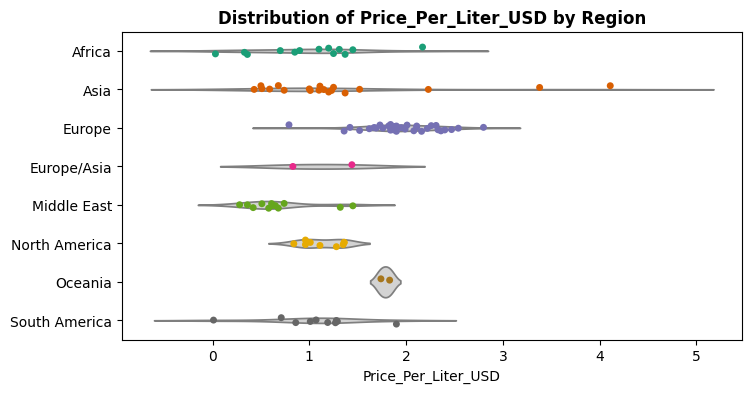

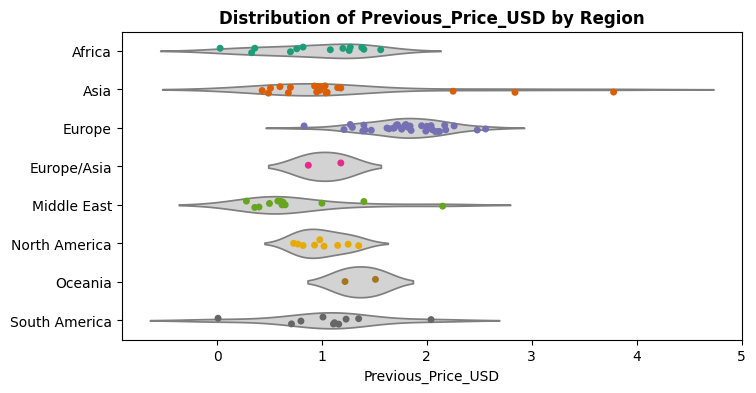

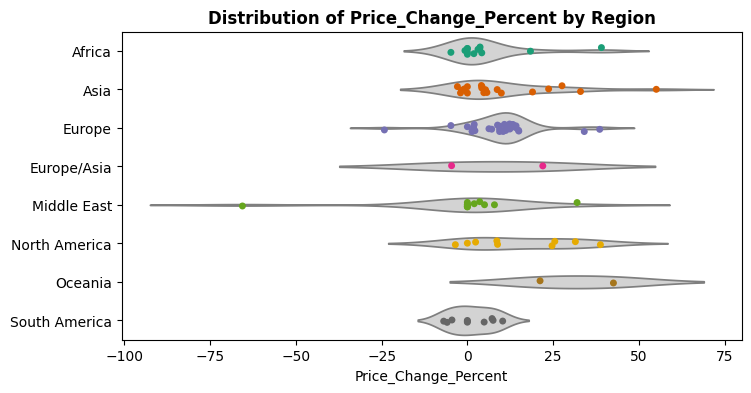

In [31]:
# Checking distributions of the data

# grouping the data by region
numeric_cols = df.select_dtypes(include=[np.number]) # selecing only numeric data
region_sortdf = df.sort_values('Region')

for col in numeric_cols:
    if col == 'Price_Per_Gallon_USD': # since both price_per_litre is the same
        continue

    plt.figure(figsize=(8, 4))
    sns.violinplot(data=region_sortdf, x=col, y='Region', legend=False, color='lightgrey', inner=None)
    sns.stripplot(data=region_sortdf, x=col, y='Region', size=5, jitter=True, palette='Dark2', hue='Region', legend=False)
    plt.title(f'Distribution of {col} by Region', fontweight='bold')
    plt.ylabel('')
    plt.grid(False)
    plt.show()

## Expensive and cheapest countries for petrol

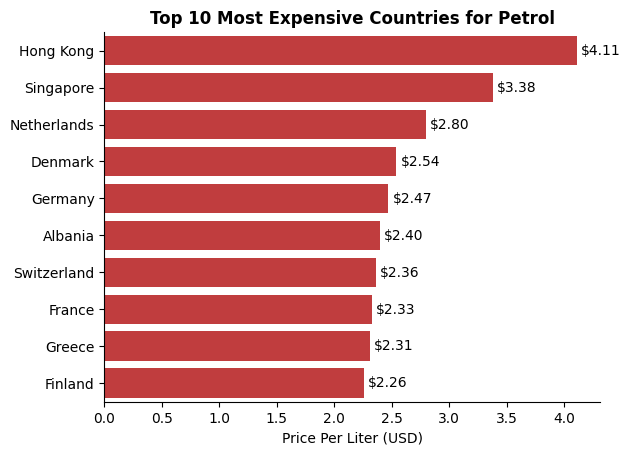

In [32]:
# Top 10 Expensive countries for petrol
top10 = df.sort_values('Price_Per_Liter_USD', ascending=False).head(10)
ax_exp = sns.barplot(data=top10, x='Price_Per_Liter_USD', y='Country', color='#d62728')

plt.title('Top 10 Most Expensive Countries for Petrol', fontweight='bold')
plt.xlabel('Price Per Liter (USD)')
plt.ylabel('') # Cleaner look
ax_exp.bar_label(ax_exp.containers[0], fmt='$%.2f', padding=3) # label for each country
sns.despine()

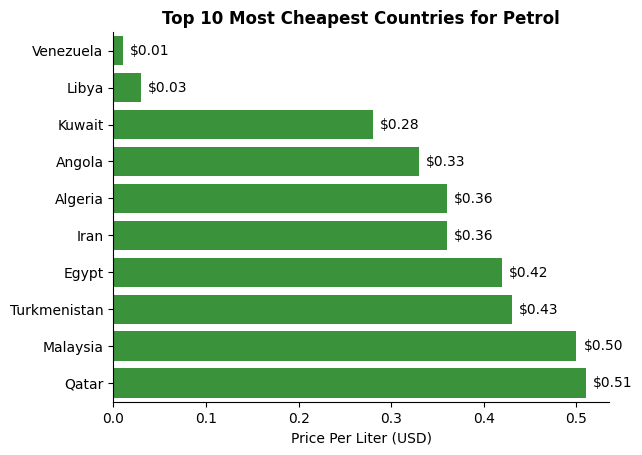

In [33]:
# Top 10 Cheapest countries for petrol
bottom10 = df.sort_values('Price_Per_Liter_USD', ascending=True).head(10)
ax_cheap = sns.barplot(data=bottom10, x='Price_Per_Liter_USD', y='Country', color='#2ca02c')
plt.title('Top 10 Most Cheapest Countries for Petrol', fontweight='bold')
plt.xlabel('Price Per Liter (USD)')
plt.ylabel('')
ax_cheap.bar_label(ax_cheap.containers[0], fmt='$%.2f', padding=5)
sns.despine();

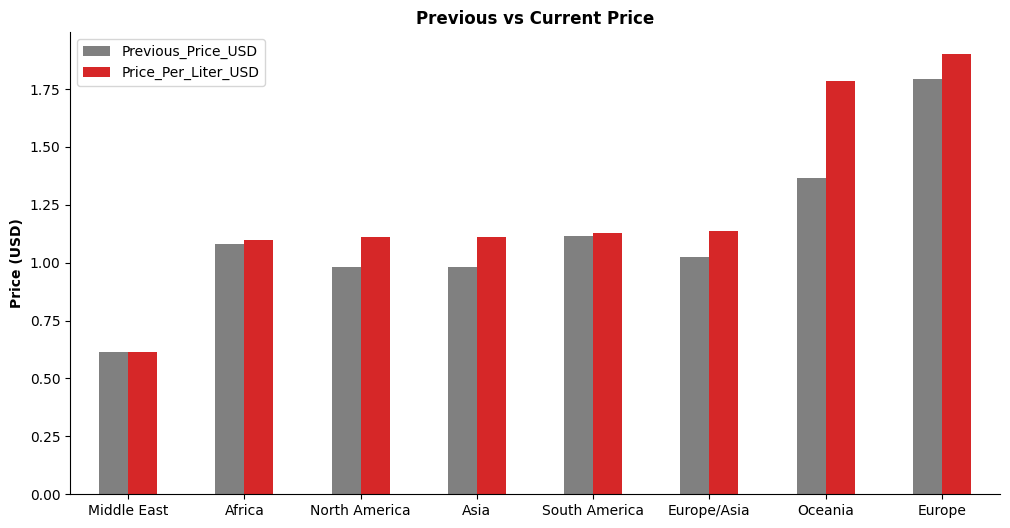

In [34]:
current_vs_previous = df.groupby('Region')[['Previous_Price_USD', 'Price_Per_Liter_USD']].median().sort_values(by='Price_Per_Liter_USD')

current_vs_previous.plot(kind='bar', figsize=(12, 6), color=['grey', '#d62728'])
plt.xlabel('')
plt.ylabel('Price (USD)', fontweight='bold')
plt.xticks(rotation=0)
plt.title("Previous vs Current Price", fontweight="bold")
sns.despine()

The middle east has seen no change in prices but the other regions have seen increase in petrol prices.

## Most volatile petrol markets

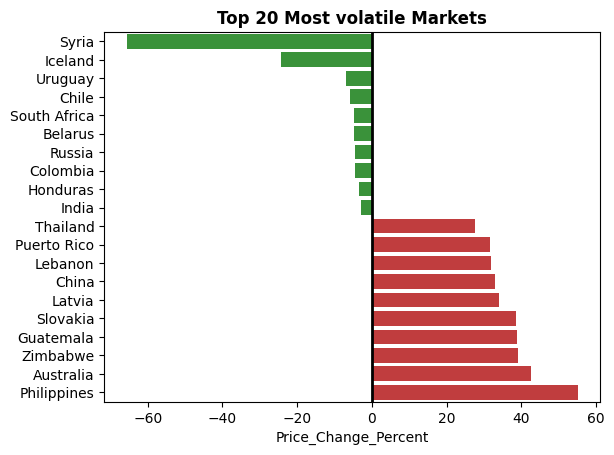

In [35]:
sorted_df = df.sort_values('Price_Change_Percent')
drops = sorted_df.head(10)
increases = sorted_df.tail(10)

volatile = pd.concat([drops, increases])

colors = ['#2ca02c' if i < 0 else '#d62728' for i in volatile['Price_Change_Percent']]
sns.barplot(data=volatile, x='Price_Change_Percent', y='Country', hue='Country', palette=colors, legend=False)
plt.title("Top 20 Most volatile Markets", fontweight='bold')
plt.axvline(0, color='black', linewidth=2)
plt.ylabel(''); # ; to suppress unwanted cell outputs

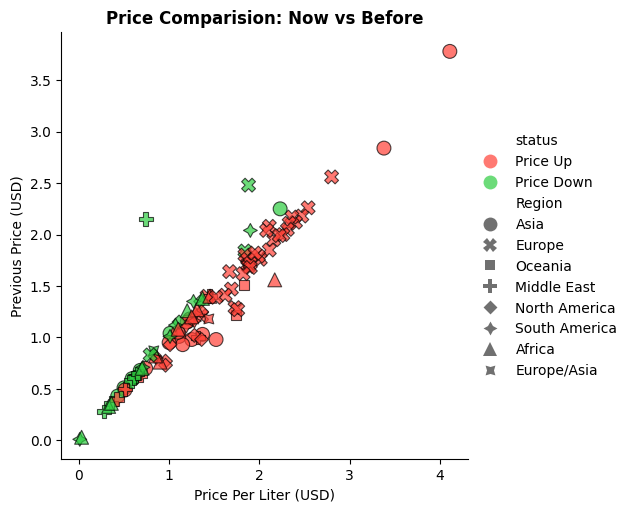

In [36]:
df['difference'] = df['Price_Per_Liter_USD'] - df['Previous_Price_USD']
df['status'] = df['difference'].apply(lambda x: 'Price Up' if x > 0 else 'Price Down')
status_colors = {"Price Up": "#FF4136", "Price Down": "#2ECC40"}

sns.relplot(data=df, x='Price_Per_Liter_USD', y='Previous_Price_USD', kind='scatter', hue='status', style='Region', palette=status_colors, alpha=0.7, edgecolor='k', s=100)
plt.title("Price Comparision: Now vs Before", fontweight="bold")
plt.xlabel('Price Per Liter (USD)')
plt.ylabel('Previous Price (USD)');

This shows that European region already had higher prices and it got worse. In middle east it is almost the same as before.

## Price trend vs Region

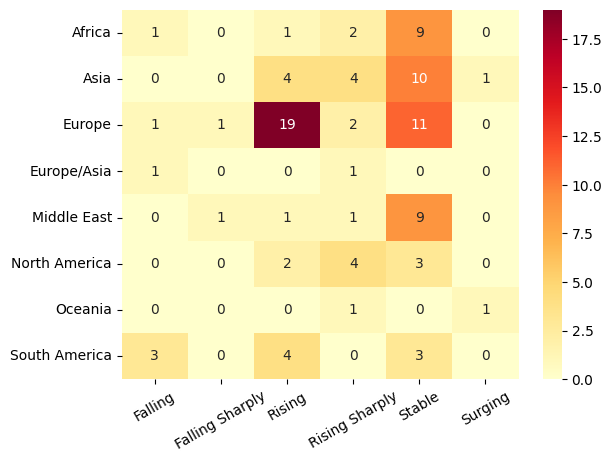

In [81]:
pivot = df.pivot_table(index='Region', columns='Price_Trend', values='Country', aggfunc='count', fill_value=0)
sns.heatmap(pivot, annot=True, cmap='YlOrRd')
plt.ylabel('')
plt.yticks(rotation=0)
plt.xticks(rotation=30)
plt.xlabel('');

This shows that the European region oil prices are rising at several places and below are the countries that are seeing rising petrol prices.

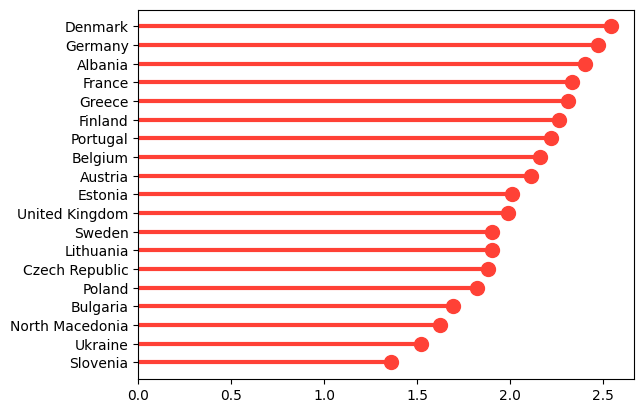

In [132]:
europe_rising = df[(df['Region'] == "Europe") & (df['Price_Trend'] == "Rising")].sort_values(by='Price_Per_Liter_USD', ascending=True)
plt.plot(europe_rising['Price_Per_Liter_USD'], europe_rising['Country'], "o", markersize=10, color='#FF4136')
plt.hlines(y=europe_rising['Country'],xmin=0, xmax=europe_rising['Price_Per_Liter_USD'], color='#FF4136', linewidth=3)
plt.xlim(0);

These are the European countries seeing a rise in petrol prices.

In [ ]:
print(europe_rising['Country'].unique())

['Slovenia' 'Ukraine' 'North Macedonia' 'Bulgaria' 'Poland'
 'Czech Republic' 'Lithuania' 'Sweden' 'United Kingdom' 'Estonia'
 'Austria' 'Belgium' 'Portugal' 'Finland' 'Greece' 'France' 'Albania'
 'Germany' 'Denmark']
